# Module 2: AF-Whisper Encoder — From Spectrogram to Audio Embeddings

> *"The encoder's job is to compress 30 seconds of audio into 1500 rich vectors that the LLM can reason about."*

This is Module 2 of our Audio Flamingo 3 series. In Module 1, we built the full audio preprocessing pipeline — raw waveform → Log Mel Spectrogram. We ended with an `(80, 3000)` tensor.

Today we build the **AF-Whisper Encoder** — the neural network that takes that tensor and produces meaningful audio representations. This is the first learned component in the pipeline.

**What we'll build:**
1. The Convolutional Stem — why conv before transformer, and what it does
2. Positional Embeddings — giving the transformer a sense of time
3. Multi-Head Self-Attention — the core of every transformer
4. The Transformer Encoder Block — MHA + FFN + LayerNorm
5. A complete `WhisperEncoder` in ~200 lines of pure PyTorch
6. A `NanoWhisperEncoder` that runs on CPU in seconds

**No pretrained weights. No HuggingFace. Just `torch.nn`.**

Run every cell. Read every comment. The comments *are* the explanation.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

plt.style.use('dark_background')
torch.manual_seed(42)

# We'll run everything on CPU — no GPU needed
DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.10.0+cpu


---
## Recap: Where We Are

Let's recreate the Log Mel Spectrogram from Module 1 so we have a real input to feed through the encoder.

In [2]:
# --- Paste the full pipeline from Module 1 ---
# (In a real project this would be an import, but we keep notebooks self-contained)

def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10.0 ** (mel / 2595.0) - 1.0)

def build_mel_filterbank(n_mels, n_fft, sample_rate, fmin=0.0, fmax=None):
    if fmax is None:
        fmax = sample_rate / 2.0
    mel_points = np.linspace(hz_to_mel(fmin), hz_to_mel(fmax), n_mels + 2)
    hz_points  = mel_to_hz(mel_points)
    n_freqs    = n_fft // 2 + 1
    bin_points = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    filterbank = np.zeros((n_mels, n_freqs))
    for m in range(1, n_mels + 1):
        f_left, f_center, f_right = bin_points[m-1], bin_points[m], bin_points[m+1]
        for k in range(f_left, f_center):
            filterbank[m-1, k] = (k - f_left) / (f_center - f_left + 1e-8)
        for k in range(f_center, f_right):
            filterbank[m-1, k] = (f_right - k) / (f_right - f_center + 1e-8)
    return filterbank

def log_mel_spectrogram(audio, sample_rate=16000, n_fft=400, hop_length=160, n_mels=80):
    window   = np.hanning(n_fft)
    n_frames = 1 + (len(audio) - n_fft) // hop_length
    n_freqs  = n_fft // 2 + 1
    power_spec = np.zeros((n_freqs, n_frames))
    for i in range(n_frames):
        start = i * hop_length
        frame = audio[start:start+n_fft] * window
        power_spec[:, i] = np.abs(np.fft.rfft(frame)) ** 2
    filterbank = build_mel_filterbank(n_mels, n_fft, sample_rate)
    mel_spec   = filterbank @ power_spec
    log_spec   = np.log10(np.maximum(mel_spec, 1e-10))
    log_spec   = np.maximum(log_spec, log_spec.max() - 8.0)
    log_spec   = (log_spec + 4.0) / 4.0
    return log_spec


# --- Create a 2-second A major chord (same as Module 1) ---
SAMPLE_RATE = 16_000
t = np.linspace(0, 2.0, int(SAMPLE_RATE * 2.0), endpoint=False)
waveform = (0.4 * np.sin(2*np.pi*440*t) +
            0.3 * np.sin(2*np.pi*554*t) +
            0.3 * np.sin(2*np.pi*659*t))

# --- Log Mel Spectrogram → PyTorch tensor ---
mel = log_mel_spectrogram(waveform)          # numpy: (80, T)
mel_tensor = torch.tensor(mel, dtype=torch.float32)  # torch: (80, T)

# Add batch dimension: (1, 80, T) — 1 audio clip in the batch
mel_batch = mel_tensor.unsqueeze(0)

print(f'Log Mel shape (numpy): {mel.shape}')
print(f'Log Mel shape (torch): {mel_batch.shape}')   # (1, 80, T)
print(f'This is what enters the encoder.')

Log Mel shape (numpy): (80, 198)
Log Mel shape (torch): torch.Size([1, 80, 198])
This is what enters the encoder.


---
## Part 1: The Convolutional Stem

The very first thing AF-Whisper does is pass the Log Mel Spectrogram through **two 1D convolutional layers**.

**Why convolution before the transformer?**

Three reasons:

1. **Local feature extraction**: Nearby time frames are correlated (a phoneme lasts ~50ms = 5 frames). Conv naturally captures these local patterns. Self-attention can do it too, but it's expensive — conv does it cheaply.

2. **Temporal downsampling**: The second conv has `stride=2`, which halves the time dimension. `3000 frames → 1500 frames`. This means the LLM sees 1500 audio tokens per 30s chunk, not 3000. This is a deliberate design choice — fewer tokens = less compute.

3. **Channel expansion**: We go from 80 mel bins to 1280 channels (Whisper large-v3's `d_model`). Each position now has a rich 1280-dim vector instead of 80 raw numbers.

The conv stem is:
```
Conv1d(80  → 1280, kernel=3, stride=1, padding=1)  →  GELU
Conv1d(1280 → 1280, kernel=3, stride=2, padding=1)  →  GELU
```

In [3]:
# --- Convolutional Stem ---

class ConvStem(nn.Module):
    """
    Whisper's convolutional stem.

    Input:  (batch, n_mels, time)     e.g. (1, 80, 3000)
    Output: (batch, d_model, time//2) e.g. (1, 1280, 1500)
    """
    def __init__(self, n_mels: int, d_model: int):
        super().__init__()
        # Conv1d: operates along the time dimension
        # kernel_size=3, padding=1 → output length = input length (for stride=1)
        self.conv1 = nn.Conv1d(
            in_channels  = n_mels,
            out_channels = d_model,
            kernel_size  = 3,
            stride       = 1,
            padding      = 1,
        )
        # stride=2 → halves the time dimension
        self.conv2 = nn.Conv1d(
            in_channels  = d_model,
            out_channels = d_model,
            kernel_size  = 3,
            stride       = 2,
            padding      = 1,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, n_mels, time)
        x = F.gelu(self.conv1(x))   # → (batch, d_model, time)
        x = F.gelu(self.conv2(x))   # → (batch, d_model, time//2)
        return x


# --- Test with our audio ---
# Use a tiny d_model for CPU speed, but show the real Whisper dimensions too
D_MODEL_NANO = 64    # our nano version
D_MODEL_REAL = 1280  # Whisper large-v3 / AF-Whisper
N_MELS       = 80

conv_stem = ConvStem(n_mels=N_MELS, d_model=D_MODEL_NANO)

print('--- ConvStem ---')
print(f'Input shape:  {mel_batch.shape}')           # (1, 80, T)
stem_out = conv_stem(mel_batch)
print(f'Output shape: {stem_out.shape}')             # (1, 64, T//2)
print(f'\nTime frames: {mel_batch.shape[2]} → {stem_out.shape[2]}  (÷2 by stride=2)')
print(f'Channels:     {mel_batch.shape[1]} → {stem_out.shape[1]}  (mel bins → d_model)')

n_params = sum(p.numel() for p in conv_stem.parameters())
print(f'\nConvStem parameters (nano): {n_params:,}')

# Real Whisper dimensions:
conv_stem_real = ConvStem(n_mels=N_MELS, d_model=D_MODEL_REAL)
n_params_real  = sum(p.numel() for p in conv_stem_real.parameters())
print(f'ConvStem parameters (real): {n_params_real:,}  (~{n_params_real/1e6:.1f}M)')

--- ConvStem ---
Input shape:  torch.Size([1, 80, 198])
Output shape: torch.Size([1, 64, 99])

Time frames: 198 → 99  (÷2 by stride=2)
Channels:     80 → 64  (mel bins → d_model)

ConvStem parameters (nano): 27,776
ConvStem parameters (real): 5,224,960  (~5.2M)


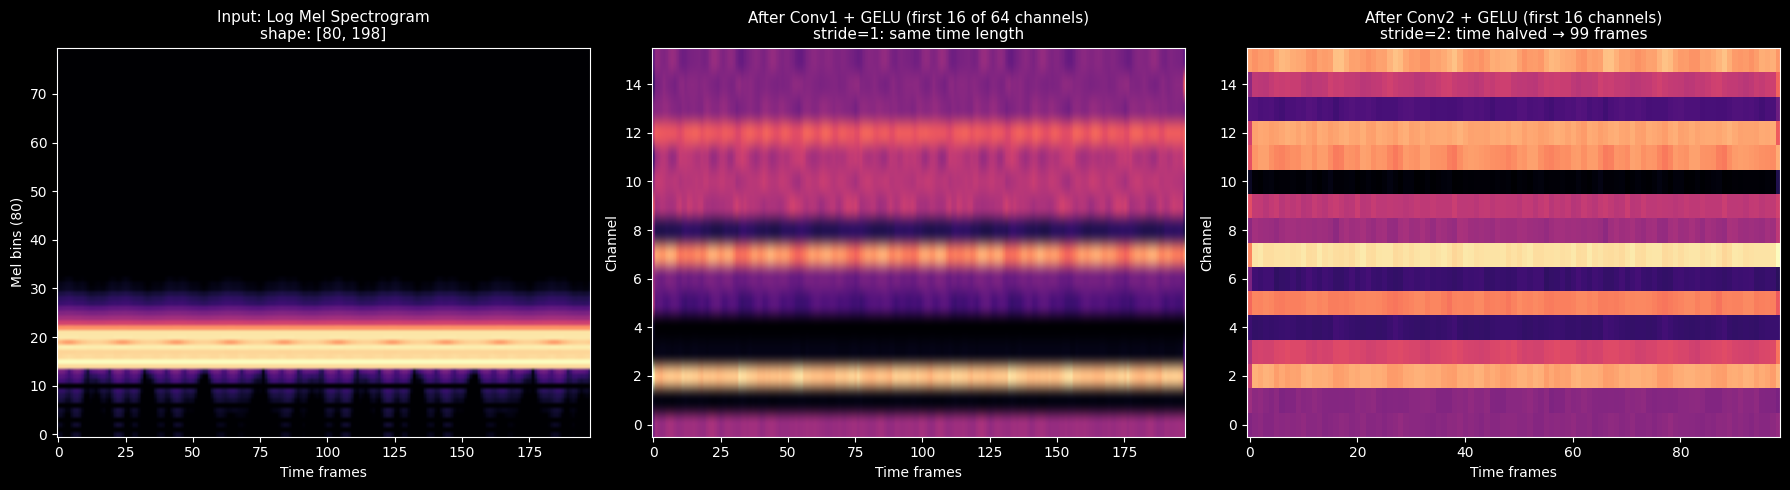

Key insight: same audio content, now represented in a richer feature space.
The time axis shrunk by 2x — this is the temporal downsampling that saves LLM compute.


In [4]:
# --- Visualize what the conv stem does ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Input: Log Mel Spectrogram
axes[0].imshow(mel_batch[0].detach().numpy(), aspect='auto', origin='lower', cmap='magma')
axes[0].set_title(f'Input: Log Mel Spectrogram\nshape: {list(mel_batch[0].shape)}', fontsize=11)
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Mel bins (80)')

# After conv1 (before GELU, for clarity)
with torch.no_grad():
    after_conv1 = F.gelu(conv_stem.conv1(mel_batch))
# Show first 16 channels
axes[1].imshow(after_conv1[0, :16].detach().numpy(), aspect='auto', origin='lower', cmap='magma')
axes[1].set_title(f'After Conv1 + GELU (first 16 of {D_MODEL_NANO} channels)\nstride=1: same time length', fontsize=11)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Channel')

# After conv2 (full stem output)
axes[2].imshow(stem_out[0, :16].detach().numpy(), aspect='auto', origin='lower', cmap='magma')
axes[2].set_title(f'After Conv2 + GELU (first 16 channels)\nstride=2: time halved → {stem_out.shape[2]} frames', fontsize=11)
axes[2].set_xlabel('Time frames')
axes[2].set_ylabel('Channel')

plt.tight_layout()
plt.show()

print('Key insight: same audio content, now represented in a richer feature space.')
print('The time axis shrunk by 2x — this is the temporal downsampling that saves LLM compute.')

---
## Part 2: Positional Embeddings

Here's the problem with transformers: **self-attention is permutation-invariant**.

If you shuffle the 1500 time frames in random order, the attention computation gives you the same result. The transformer has no idea that frame 100 comes before frame 101. That's catastrophic for audio — timing is everything.

The solution: **add a positional embedding** to each frame — a unique vector that encodes its position in the sequence.

Whisper uses **learned sinusoidal positional embeddings** — an `nn.Embedding` layer with exactly 1500 positions (for 30s of audio at the downsampled rate). This is a simple lookup table: position 0 gets vector `E[0]`, position 1 gets `E[1]`, etc.

**Why sinusoidal?** The classic "Attention Is All You Need" paper used fixed sinusoidal functions. Whisper's embeddings are *initialized* sinusoidally but then learned during training — they start structured and then adapt.

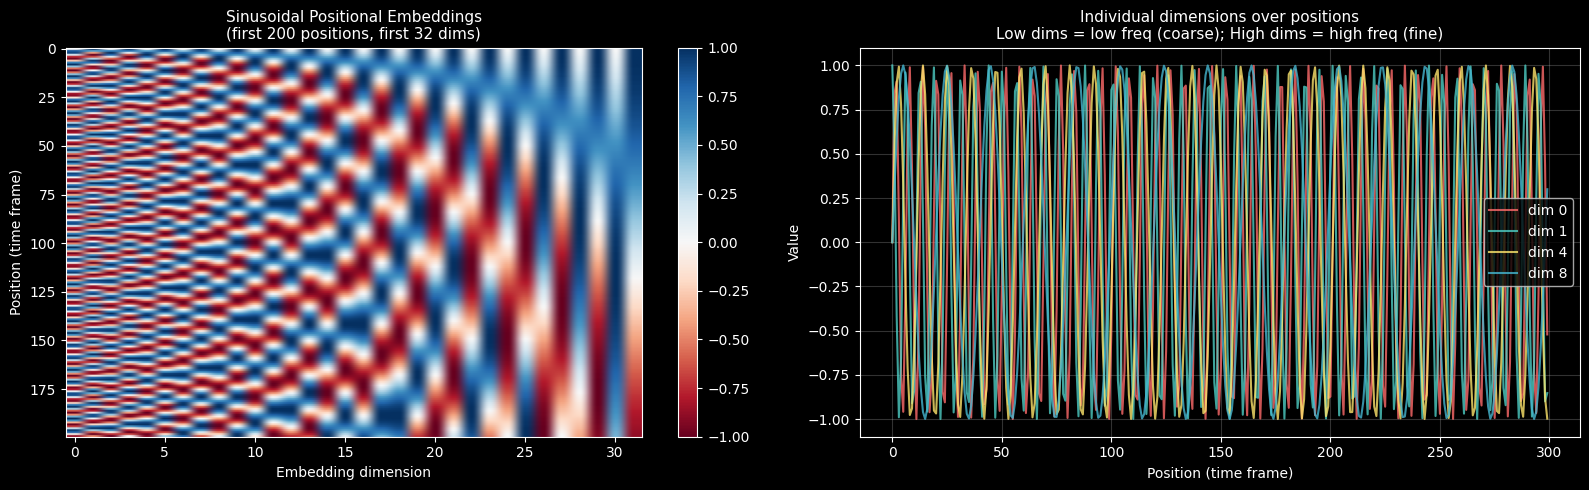

Each position gets a unique fingerprint — a combination of slow and fast oscillations.
Position 100 and position 101 are similar (nearby) but distinguishable.
This gives the transformer a sense of "where in time" each frame is.


In [5]:
# --- Positional Embeddings ---

def sinusoidal_init(n_positions: int, d_model: int) -> torch.Tensor:
    """
    Create sinusoidal positional embeddings (Vaswani et al., 2017).

    For each position p and dimension i:
        PE[p, 2i]   = sin(p / 10000^(2i/d_model))
        PE[p, 2i+1] = cos(p / 10000^(2i/d_model))

    Returns: (n_positions, d_model)
    """
    positions = torch.arange(n_positions).unsqueeze(1)        # (n_pos, 1)
    dims      = torch.arange(0, d_model, 2).float()           # (d_model//2,)
    # The scaling factor: larger dims → higher frequency → finer position detail
    div_term  = torch.pow(10000.0, dims / d_model)            # (d_model//2,)

    pe = torch.zeros(n_positions, d_model)
    pe[:, 0::2] = torch.sin(positions / div_term)  # even dims → sin
    pe[:, 1::2] = torch.cos(positions / div_term)  # odd dims  → cos
    return pe


class PositionalEmbedding(nn.Module):
    """
    Learned positional embeddings, sinusoidally initialized.
    Whisper has exactly 1500 positions (30s / 20ms per frame after stride-2 conv).
    """
    def __init__(self, n_positions: int, d_model: int):
        super().__init__()
        # nn.Embedding is just a matrix of shape (n_positions, d_model)
        # .weight is the learnable parameter
        self.embedding = nn.Embedding(n_positions, d_model)
        # Initialize with sinusoidal values instead of random
        self.embedding.weight.data = sinusoidal_init(n_positions, d_model)
        self.n_positions = n_positions

    def forward(self, seq_len: int) -> torch.Tensor:
        """
        Returns positional embeddings for positions 0..seq_len-1.
        Shape: (seq_len, d_model)
        """
        positions = torch.arange(seq_len, device=self.embedding.weight.device)
        return self.embedding(positions)  # lookup: (seq_len, d_model)


# --- Visualize positional embeddings ---
N_POSITIONS = 1500  # Whisper's fixed value for 30s audio
pe = sinusoidal_init(N_POSITIONS, D_MODEL_NANO)  # (1500, 64) for nano

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap: each row = one position's embedding
axes[0].imshow(pe[:200, :32].numpy(), aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title('Sinusoidal Positional Embeddings\n(first 200 positions, first 32 dims)', fontsize=11)
axes[0].set_xlabel('Embedding dimension')
axes[0].set_ylabel('Position (time frame)')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Show individual dimensions — each is a sine/cosine at a different frequency
for i, (dim, color) in enumerate([(0, '#FF6B6B'), (1, '#4ECDC4'), (4, '#FFE66D'), (8, '#45B7D1')]):
    axes[1].plot(pe[:300, dim].numpy(), color=color, lw=1.5, label=f'dim {dim}', alpha=0.8)
axes[1].set_title('Individual dimensions over positions\nLow dims = low freq (coarse); High dims = high freq (fine)', fontsize=11)
axes[1].set_xlabel('Position (time frame)')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print('Each position gets a unique fingerprint — a combination of slow and fast oscillations.')
print('Position 100 and position 101 are similar (nearby) but distinguishable.')
print('This gives the transformer a sense of "where in time" each frame is.')

---
## Part 3: Multi-Head Self-Attention

This is the core of the transformer. Let's build it properly.

**The intuition:** Each time frame looks at all other time frames and asks: *"which frames are relevant to me?"* The answer becomes a weighted average of all frames' values.

**The mechanics:**
- Every frame is projected into three vectors: **Query (Q)**, **Key (K)**, **Value (V)**
- Attention score between frame i and frame j: `dot(Q_i, K_j) / sqrt(d_k)`
- Softmax over scores → attention weights (sum to 1)
- Output for frame i: weighted sum of all V vectors

**Multi-head:** Do this `n_heads` times in parallel, each with different projections. Each head can attend to different aspects (pitch, rhythm, timbre...). Concatenate all heads.

Whisper large-v3 uses **20 heads** with `d_model=1280`, so each head has `d_k = 1280/20 = 64` dims.

MHSA input shape: torch.Size([1, 99, 64])
MHSA output shape: torch.Size([1, 99, 64])
Attention weights shape: torch.Size([1, 4, 99, 99])


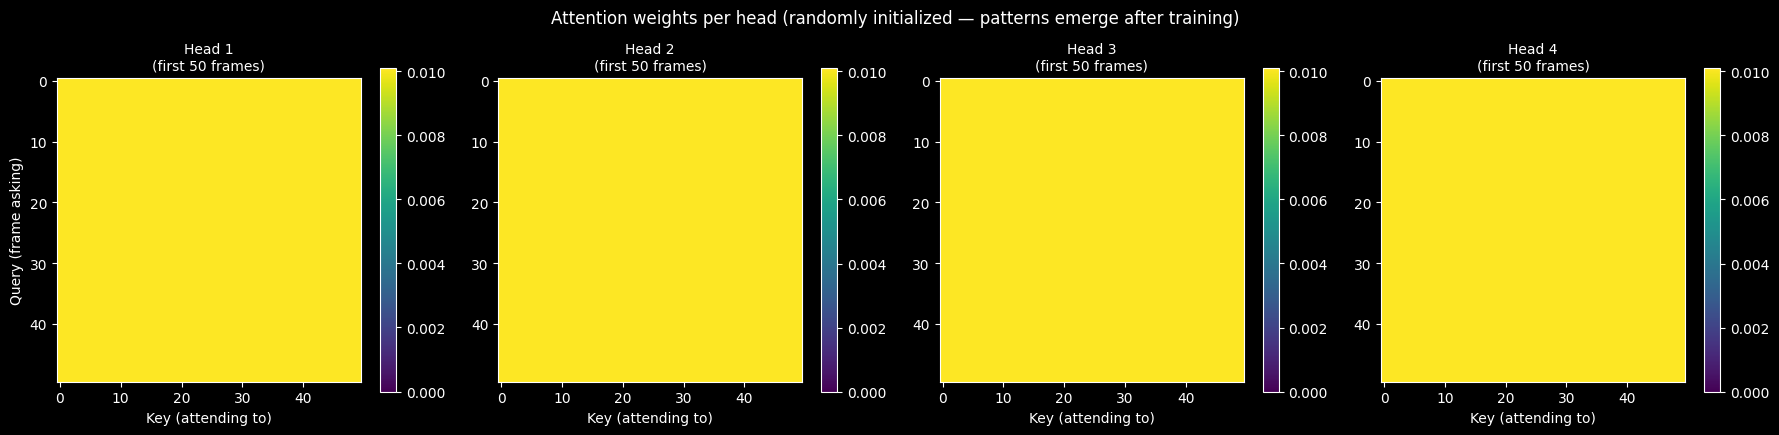


After training, different heads learn different patterns:
  - Some heads attend locally (nearby frames, for phoneme-level patterns)
  - Some heads attend globally (distant frames, for musical structure)
  - This is why "multi-head" is more powerful than single attention


In [6]:
# --- Multi-Head Self-Attention from scratch ---

class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention (Vaswani et al., 2017).

    Input/Output shape: (batch, seq_len, d_model)
    """
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0, 'd_model must be divisible by n_heads'

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads  # dimension per head

        # Q, K, V projections — one linear layer per projection
        # (We could also do a single (d_model, 3*d_model) projection and split,
        #  but separate layers are clearer for learning purposes)
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)

        # Output projection: combines all heads back to d_model
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, seq_len, d_model)
        Returns:
            (batch, seq_len, d_model)  — same shape, richer content
        """
        B, T, D = x.shape  # batch, time (seq_len), d_model

        # 1. Project to Q, K, V
        Q = self.q_proj(x)  # (B, T, D)
        K = self.k_proj(x)  # (B, T, D)
        V = self.v_proj(x)  # (B, T, D)

        # 2. Split into heads
        # Reshape: (B, T, D) → (B, T, n_heads, d_k) → (B, n_heads, T, d_k)
        Q = Q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)  # (B, H, T, d_k)
        K = K.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # 3. Scaled dot-product attention
        # scores[b, h, i, j] = how much frame i attends to frame j (for head h)
        scale  = math.sqrt(self.d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale  # (B, H, T, T)
        weights = F.softmax(scores, dim=-1)                      # (B, H, T, T) — rows sum to 1

        # 4. Weighted sum of Values
        attended = torch.matmul(weights, V)  # (B, H, T, d_k)

        # 5. Merge heads
        # (B, H, T, d_k) → (B, T, H, d_k) → (B, T, D)
        attended = attended.transpose(1, 2).contiguous().view(B, T, D)

        # 6. Output projection
        out = self.out_proj(attended)  # (B, T, D)
        return out, weights  # return weights so we can visualize them


# --- Test and visualize attention ---
N_HEADS = 4   # nano: 4 heads with d_model=64 → d_k=16 per head
             # real: 20 heads with d_model=1280 → d_k=64 per head

mhsa = MultiHeadSelfAttention(d_model=D_MODEL_NANO, n_heads=N_HEADS)

# Prepare input: conv stem output, transposed to (batch, seq_len, d_model)
stem_out_transposed = stem_out.transpose(1, 2)  # (1, T//2, 64)
print(f'MHSA input shape: {stem_out_transposed.shape}')

with torch.no_grad():
    attn_out, attn_weights = mhsa(stem_out_transposed)

print(f'MHSA output shape: {attn_out.shape}')        # same as input!
print(f'Attention weights shape: {attn_weights.shape}')  # (B, H, T, T)

# Visualize attention patterns (random init — just to see the structure)
fig, axes = plt.subplots(1, N_HEADS, figsize=(18, 4))
T_viz = min(50, attn_weights.shape[-1])  # show first 50 frames

for h in range(N_HEADS):
    im = axes[h].imshow(
        attn_weights[0, h, :T_viz, :T_viz].detach().numpy(),
        cmap='viridis', vmin=0
    )
    axes[h].set_title(f'Head {h+1}\n(first {T_viz} frames)', fontsize=10)
    axes[h].set_xlabel('Key (attending to)')
    if h == 0: axes[h].set_ylabel('Query (frame asking)')
    plt.colorbar(im, ax=axes[h])

plt.suptitle('Attention weights per head (randomly initialized — patterns emerge after training)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\nAfter training, different heads learn different patterns:')
print('  - Some heads attend locally (nearby frames, for phoneme-level patterns)')
print('  - Some heads attend globally (distant frames, for musical structure)')
print('  - This is why "multi-head" is more powerful than single attention')

---
## Part 4: The Feed-Forward Network and LayerNorm

A transformer block has two sub-layers:
1. Multi-Head Self-Attention (built above)
2. **Feed-Forward Network (FFN)** — applied independently to each position

Both are wrapped with **residual connections** and **Layer Normalization**.

The FFN is simple: two linear layers with GELU in between. The hidden dim is 4× the model dim (Whisper: 1280 → 5120 → 1280).

**Why residual connections?** They allow gradients to flow directly backwards through the network, enabling training of very deep networks (32 layers in Whisper large-v3).

**Why LayerNorm?** Normalizes the activations across the feature dimension, stabilizing training. Whisper uses **Pre-Norm** (LayerNorm before each sub-layer) rather than Post-Norm.

In [7]:
# --- Feed-Forward Network ---

class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network.
    Applied identically to each time step — like a 1x1 conv across channels.

    Input/Output: (batch, seq_len, d_model)
    Hidden dim:   d_model * 4  (Whisper's ratio)
    """
    def __init__(self, d_model: int):
        super().__init__()
        d_ff = d_model * 4  # 1280 → 5120 in Whisper large-v3
        self.fc1  = nn.Linear(d_model, d_ff)
        self.fc2  = nn.Linear(d_ff, d_model)
        # GELU (Gaussian Error Linear Unit) — smoother than ReLU, preferred in modern transformers

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = F.gelu(self.fc1(x))  # → (batch, seq_len, d_ff)
        x = self.fc2(x)          # → (batch, seq_len, d_model)
        return x


# --- Full Transformer Encoder Block ---

class TransformerEncoderBlock(nn.Module):
    """
    One Whisper-style encoder block.

    Architecture (Pre-Norm):
        x = x + MHSA(LayerNorm(x))   ← attention sub-layer
        x = x + FFN(LayerNorm(x))    ← feed-forward sub-layer

    The residual (x + ...) is key: gradients can bypass each sub-layer entirely.
    """
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)  # before attention
        self.attn  = MultiHeadSelfAttention(d_model, n_heads)
        self.norm2 = nn.LayerNorm(d_model)  # before FFN
        self.ffn   = FeedForward(d_model)

    def forward(self, x: torch.Tensor):
        # x: (batch, seq_len, d_model)

        # Sub-layer 1: Multi-Head Self-Attention (Pre-Norm)
        attn_out, weights = self.attn(self.norm1(x))
        x = x + attn_out           # residual connection

        # Sub-layer 2: Feed-Forward Network (Pre-Norm)
        x = x + self.ffn(self.norm2(x))  # residual connection

        return x, weights


# --- Test one block ---
block = TransformerEncoderBlock(d_model=D_MODEL_NANO, n_heads=N_HEADS)

with torch.no_grad():
    block_out, block_weights = block(stem_out_transposed)

print(f'Encoder block input:  {stem_out_transposed.shape}')
print(f'Encoder block output: {block_out.shape}')   # same shape!
print(f'→ Each block preserves shape. We stack N_LAYERS of them.')

n_params_block = sum(p.numel() for p in block.parameters())
print(f'\nParams per block (nano):  {n_params_block:,}')
print(f'Params per block (real):  ~{4 * D_MODEL_REAL**2 * (1 + 1/D_MODEL_REAL*4) / 1e6:.1f}M')
print(f'  (real Whisper: 32 blocks × ~13M params/block = ~416M params in the encoder alone)')

Encoder block input:  torch.Size([1, 99, 64])
Encoder block output: torch.Size([1, 99, 64])
→ Each block preserves shape. We stack N_LAYERS of them.

Params per block (nano):  49,728
Params per block (real):  ~6.6M
  (real Whisper: 32 blocks × ~13M params/block = ~416M params in the encoder alone)


---
## Part 5: The Complete WhisperEncoder

Now we assemble all the pieces:

```
ConvStem → Positional Embedding → [TransformerBlock × N_LAYERS] → LayerNorm
```

The final LayerNorm is applied once at the end (standard in Whisper's Pre-Norm architecture).

In [8]:
# --- Complete WhisperEncoder ---

class WhisperEncoder(nn.Module):
    """
    A faithful reimplementation of Whisper's audio encoder.
    This is also the architecture of AF-Whisper in Audio Flamingo 3.

    AF-Whisper differs from vanilla Whisper only in:
    - Pretraining data (50M audio-text pairs vs speech-only)
    - Training strategy (joint sound+music+speech representation learning)
    The architecture is identical.

    Input:  (batch, n_mels, time)              e.g. (1, 80, 3000)
    Output: (batch, time//2, d_model)          e.g. (1, 1500, 1280)
                                               = 1500 rich audio embeddings
    """
    def __init__(self,
                 n_mels:      int = 80,
                 d_model:     int = 1280,
                 n_heads:     int = 20,
                 n_layers:    int = 32,
                 n_positions: int = 1500):
        super().__init__()

        # 1. Convolutional stem: (B, n_mels, T) → (B, d_model, T//2)
        self.conv_stem = ConvStem(n_mels, d_model)

        # 2. Positional embeddings: one vector per position (0..n_positions-1)
        self.pos_embed = PositionalEmbedding(n_positions, d_model)

        # 3. Stack of transformer encoder blocks
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(d_model, n_heads)
            for _ in range(n_layers)
        ])

        # 4. Final layer norm (after all blocks)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, mel: torch.Tensor):
        """
        Args:
            mel: Log Mel Spectrogram, shape (batch, n_mels, time)
        Returns:
            embeddings: (batch, time//2, d_model)
        """
        # 1. Conv stem: extract local features + downsample time
        x = self.conv_stem(mel)           # (B, d_model, T//2)

        # 2. Transpose for transformer: (B, d_model, T//2) → (B, T//2, d_model)
        x = x.transpose(1, 2)            # (B, T//2, d_model)

        # 3. Add positional embeddings
        seq_len = x.shape[1]
        x = x + self.pos_embed(seq_len)  # broadcast: (T//2, d_model) adds to (B, T//2, d_model)

        # 4. Pass through transformer blocks
        all_weights = []
        for block in self.blocks:
            x, weights = block(x)
            all_weights.append(weights)

        # 5. Final layer norm
        x = self.norm(x)                 # (B, T//2, d_model)

        return x, all_weights


# --- Instantiate the NANO version (runs on CPU) ---
# Whisper large-v3 / AF-Whisper: d_model=1280, n_heads=20, n_layers=32
# Our nano:                       d_model=64,   n_heads=4,  n_layers=2

encoder_nano = WhisperEncoder(
    n_mels      = 80,
    d_model     = D_MODEL_NANO,   # 64
    n_heads     = N_HEADS,        # 4
    n_layers    = 2,              # 2 blocks instead of 32
    n_positions = 1500,
)

print('--- NanoWhisperEncoder ---')
with torch.no_grad():
    embeddings, all_weights = encoder_nano(mel_batch)

print(f'Input:  {mel_batch.shape}         (batch, n_mels, time)')
print(f'Output: {embeddings.shape}  (batch, time//2, d_model)')
print(f'\nThese {embeddings.shape[1]} vectors are the "audio tokens" the LLM will read.')

n_params_total = sum(p.numel() for p in encoder_nano.parameters())
print(f'\nNano encoder parameters: {n_params_total:,}')

# Real model parameter count
encoder_real = WhisperEncoder(80, 1280, 20, 32, 1500)
n_params_real = sum(p.numel() for p in encoder_real.parameters())
print(f'Real encoder parameters: {n_params_real:,}  (~{n_params_real/1e9:.2f}B)')
del encoder_real  # free memory

--- NanoWhisperEncoder ---
Input:  torch.Size([1, 80, 198])         (batch, n_mels, time)
Output: torch.Size([1, 99, 64])  (batch, time//2, d_model)

These 99 vectors are the "audio tokens" the LLM will read.

Nano encoder parameters: 223,360
Real encoder parameters: 636,661,760  (~0.64B)


---
## Part 6: Inspecting the Embeddings

Let's look at what our nano encoder produces and verify it makes sense.

Embedding matrix shape: (99, 64)
  → 99 time steps, each described by 64 numbers


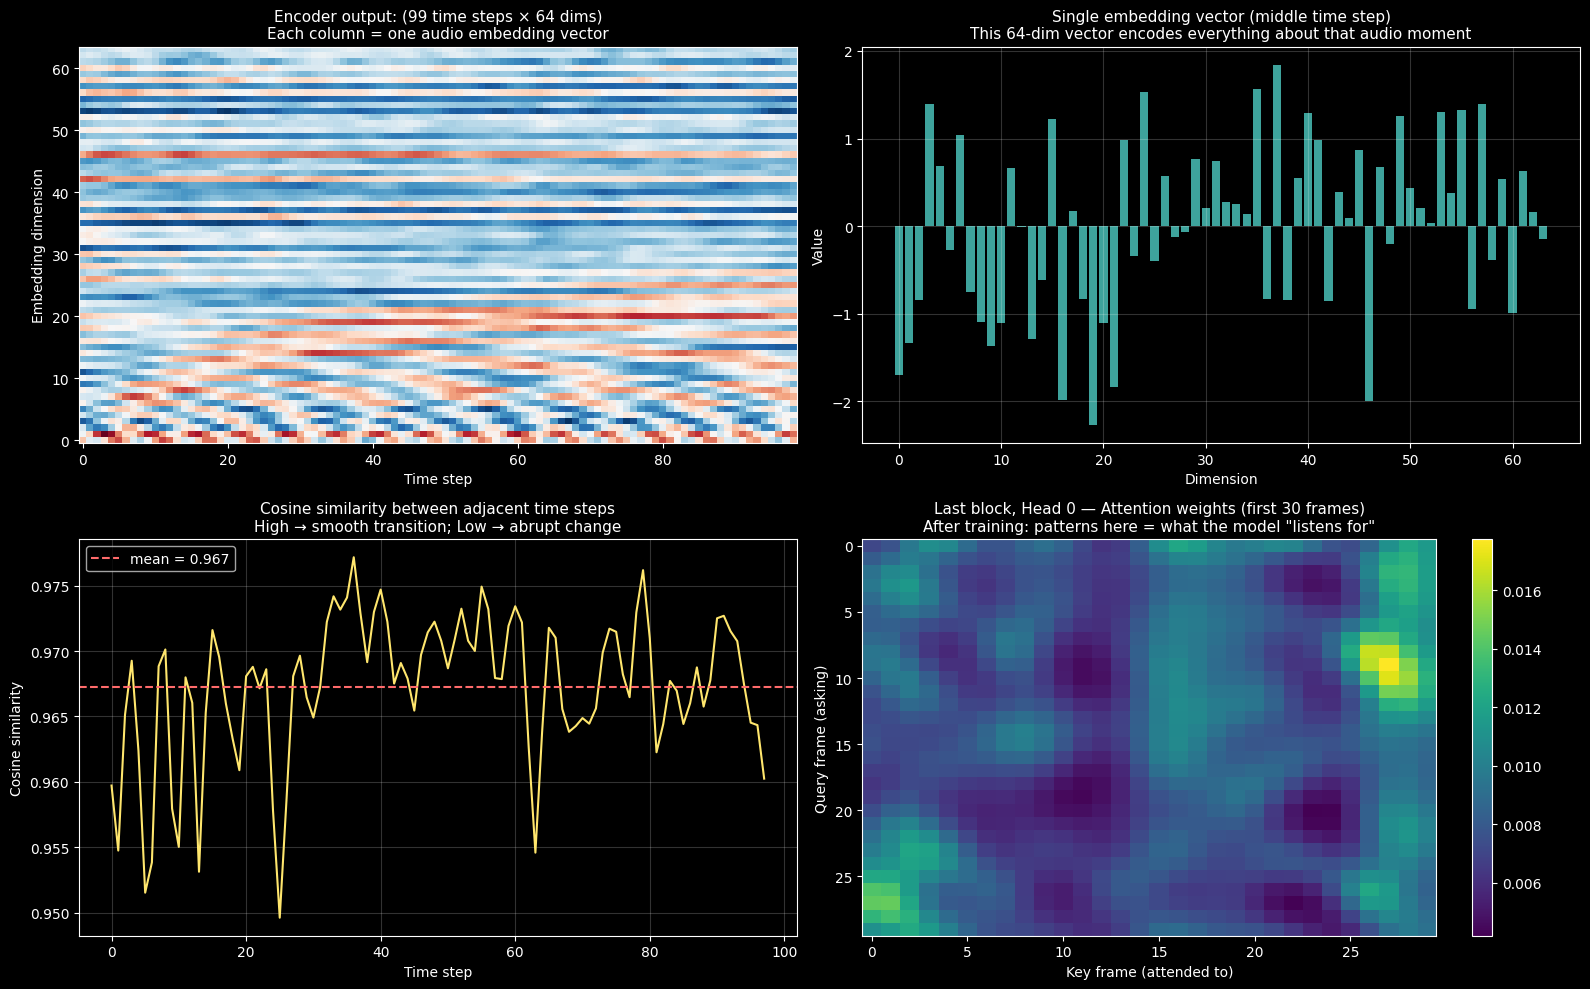

In [9]:
# --- Analyze the output embeddings ---

emb = embeddings[0].detach().numpy()  # (T//2, d_model)
print(f'Embedding matrix shape: {emb.shape}')
print(f'  → {emb.shape[0]} time steps, each described by {emb.shape[1]} numbers')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Embedding heatmap — each row is one time step's embedding vector
axes[0,0].imshow(emb.T, aspect='auto', cmap='RdBu', origin='lower')
axes[0,0].set_title(f'Encoder output: ({emb.shape[0]} time steps × {emb.shape[1]} dims)\n'
                    f'Each column = one audio embedding vector', fontsize=11)
axes[0,0].set_xlabel('Time step')
axes[0,0].set_ylabel('Embedding dimension')

# 2. Single embedding vector
axes[0,1].bar(range(D_MODEL_NANO), emb[emb.shape[0]//2], color='#4ECDC4', alpha=0.8)
axes[0,1].set_title(f'Single embedding vector (middle time step)\n'
                    f'This 64-dim vector encodes everything about that audio moment', fontsize=11)
axes[0,1].set_xlabel('Dimension')
axes[0,1].set_ylabel('Value')
axes[0,1].grid(alpha=0.2)

# 3. How similar are adjacent time steps?
# Cosine similarity between each consecutive pair
similarities = []
for i in range(len(emb) - 1):
    a, b = emb[i], emb[i+1]
    cos_sim = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)
    similarities.append(cos_sim)

axes[1,0].plot(similarities, color='#FFE66D', lw=1.5)
axes[1,0].set_title(f'Cosine similarity between adjacent time steps\n'
                    f'High → smooth transition; Low → abrupt change', fontsize=11)
axes[1,0].set_xlabel('Time step')
axes[1,0].set_ylabel('Cosine similarity')
axes[1,0].axhline(np.mean(similarities), color='#FF6B6B', linestyle='--',
                   label=f'mean = {np.mean(similarities):.3f}')
axes[1,0].legend()
axes[1,0].grid(alpha=0.2)

# 4. Attention weights from last block
last_weights = all_weights[-1][0, 0, :30, :30].detach().numpy()  # head 0, first 30×30
im = axes[1,1].imshow(last_weights, cmap='viridis', aspect='auto')
axes[1,1].set_title('Last block, Head 0 — Attention weights (first 30 frames)\n'
                    'After training: patterns here = what the model "listens for"', fontsize=11)
axes[1,1].set_xlabel('Key frame (attended to)')
axes[1,1].set_ylabel('Query frame (asking)')
plt.colorbar(im, ax=axes[1,1])

plt.tight_layout()
plt.show()

---
## Part 7: The Full Picture — Connecting Modules 1 and 2

In [11]:
# --- End-to-end: raw audio → audio embeddings ---

def encode_audio(waveform: np.ndarray, encoder: WhisperEncoder) -> torch.Tensor:
    """
    Full pipeline: raw audio → audio embeddings ready for the LLM.

    This is exactly what AF3 does before passing audio to Qwen-2.5.
    """
    # Step 1 (Module 1): Waveform → Log Mel Spectrogram
    mel = log_mel_spectrogram(waveform)                                  # (80, T)
    mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)     # (1, 80, T)

    # Step 2 (Module 2): Mel → Audio Embeddings
    with torch.no_grad():
        embeddings, _ = encoder(mel_tensor)                              # (1, T//2, d_model)

    return embeddings


# Test it
audio_embeddings = encode_audio(waveform, encoder_nano)
print('=== End-to-End Pipeline ===')
print(f'Raw audio:        {waveform.shape}     (32,000 samples = 2 seconds at 16kHz)')
print(f'Log Mel Spec:     (80, ~200)            (80 mel bins × ~200 time frames)')
print(f'Audio Embeddings: {audio_embeddings.shape}    (batch × audio_tokens × d_model)')
print()

diagram = """
┌──────────────────────────────────────────────────────────────────────┐
│              Audio Flamingo 3 — Updated Pipeline                     │
│                                                                      │
│  RAW AUDIO (waveform, 16kHz)                                         │
│       │                                                              │
│       ▼  Module 1 ✓                                                  │
│  LOG MEL SPECTROGRAM  (80, T)                                        │
│       │                                                              │
│       ▼  Module 2 ✓                                                  │
│  AF-WHISPER ENCODER                                                  │
│  ├─ ConvStem:    (80, T) → (1280, T//2)   local features + downsamp  │
│  ├─ PosEmbed:   + positional fingerprint per time step               │
│  ├─ 32× TransformerBlock: MHSA + FFN + residuals                     │
│  └─ LayerNorm                                                        │
│  Output: (1500, 1280)  ← 1500 rich audio embeddings                  │
│       │                                                              │
│       ▼  Module 4 (coming up)                                        │
│  AUDIO PROJECTOR (MLP)                                               │
│  Maps dim 1280 → dim 3584 (Qwen-2.5 7B's embedding dim)             │
│       │                                                              │
│       ▼  Module 4                                                    │
│  QWEN-2.5 7B                                                         │
│  1500 audio tokens + text tokens → answer                            │
└──────────────────────────────────────────────────────────────────────┘
"""
print(diagram)

print('Key numbers to remember:')
print('  30s audio → 3000 mel frames → 1500 audio tokens (after stride-2 conv)')
print('  Each token: 1280-dim vector (Whisper large-v3 / AF-Whisper)')
print('  1500 audio tokens ≈ cost of 1500 text tokens in the LLM context window')
print('  10 min audio = 20 chunks × 1500 = 30,000 audio tokens (AF3\'s max)')

=== End-to-End Pipeline ===
Raw audio:        (32000,)     (32,000 samples = 2 seconds at 16kHz)
Log Mel Spec:     (80, ~200)            (80 mel bins × ~200 time frames)
Audio Embeddings: torch.Size([1, 99, 64])    (batch × audio_tokens × d_model)


┌──────────────────────────────────────────────────────────────────────┐
│              Audio Flamingo 3 — Updated Pipeline                     │
│                                                                      │
│  RAW AUDIO (waveform, 16kHz)                                         │
│       │                                                              │
│       ▼  Module 1 ✓                                                  │
│  LOG MEL SPECTROGRAM  (80, T)                                        │
│       │                                                              │
│       ▼  Module 2 ✓                                                  │
│  AF-WHISPER ENCODER                                                  │
│  ├─ ConvStem:    (

---
## Part 8: AF-Whisper vs Vanilla Whisper — What NVIDIA Changed

The architecture is identical. The difference is in **how it was trained**.

In [12]:
comparison = """
┌──────────────────────┬───────────────────────┬──────────────────────────────┐
│                      │  Whisper large-v3      │  AF-Whisper (AF3)            │
├──────────────────────┼───────────────────────┼──────────────────────────────┤
│ Architecture         │  Conv + 32×Transformer │  Identical                   │
│ d_model              │  1280                  │  1280                        │
│ n_heads              │  20                    │  20                          │
│ n_layers             │  32                    │  32                          │
│ Parameters           │  ~637M                 │  ~637M                       │
├──────────────────────┼───────────────────────┼──────────────────────────────┤
│ Pretraining data     │  Speech only           │  Sound + Music + Speech      │
│ Training pairs       │  680K hours speech     │  ~50M audio-text pairs       │
│ Training objective   │  ASR (transcription)   │  Joint contrastive + caption │
│ Modality coverage    │  Speech                │  All 3 audio modalities      │
├──────────────────────┼───────────────────────┼──────────────────────────────┤
│ What it's good at    │  Speech transcription  │  Sound, music, AND speech    │
│ Used in              │  Standalone ASR        │  AF3 (as the audio encoder)  │
└──────────────────────┴───────────────────────┴──────────────────────────────┘

The key insight: Whisper's encoder is a powerful audio feature extractor.
NVIDIA kept the architecture, threw away the weights, and retrained it on
a much more diverse audio dataset. The result (AF-Whisper) understands music
and environmental sounds — not just speech.

This is the "transfer learning" trick: the architecture generalizes,
the weights specialize.
"""
print(comparison)


┌──────────────────────┬───────────────────────┬──────────────────────────────┐
│                      │  Whisper large-v3      │  AF-Whisper (AF3)            │
├──────────────────────┼───────────────────────┼──────────────────────────────┤
│ Architecture         │  Conv + 32×Transformer │  Identical                   │
│ d_model              │  1280                  │  1280                        │
│ n_heads              │  20                    │  20                          │
│ n_layers             │  32                    │  32                          │
│ Parameters           │  ~637M                 │  ~637M                       │
├──────────────────────┼───────────────────────┼──────────────────────────────┤
│ Pretraining data     │  Speech only           │  Sound + Music + Speech      │
│ Training pairs       │  680K hours speech     │  ~50M audio-text pairs       │
│ Training objective   │  ASR (transcription)   │  Joint contrastive + caption │
│ Modality coverage    │  Spee

---
## Summary

Here's everything you built today:

| Component | Input | Output | Why |
|-----------|-------|--------|-----|
| ConvStem | `(B, 80, T)` | `(B, 1280, T/2)` | Local features + temporal downsampling |
| PosEmbed | position index | `(T/2, 1280)` | Gives transformer sense of time order |
| MHSA | `(B, T/2, 1280)` | `(B, T/2, 1280)` | Every frame attends to every other |
| FFN | `(B, T/2, 1280)` | `(B, T/2, 1280)` | Per-position nonlinear transform |
| 32× Block | `(B, T/2, 1280)` | `(B, T/2, 1280)` | Deep representation learning |
| LayerNorm | `(B, T/2, 1280)` | `(B, T/2, 1280)` | Stabilize activations at the end |

**Final output:** 1500 vectors of dim 1280. These are the "audio tokens" passed to the LLM.

**Next up: Module 3 — CLAP**: before we connect the encoder to an LLM, we need to understand how audio and language are aligned in a shared embedding space. CLAP is the bridge — and it's what AF-CLAP (used in AF2) builds on.

---
## Exercises (do these before Module 3)

1. **Change n_layers**: set `n_layers=1` vs `n_layers=4` in `WhisperEncoder`. How does the output embedding change? Print the mean and std of the embeddings in both cases.

2. **Understand the bottleneck**: what happens if `d_model=8` and `n_heads=2`? Does the encoder still run? What does this tell you about the minimum useful representation size?

3. **Count the FLOPs manually**: for one transformer block with `d_model=64, seq_len=100`, calculate the number of multiplications in (a) the MHSA Q/K/V projections, (b) the attention scores, (c) the FFN. Which dominates for short sequences? For long sequences?

4. **The stride tradeoff**: change `ConvStem.conv2` to `stride=4` (instead of 2). Now 3000 frames → 750 tokens. What do you gain (LLM context savings)? What do you lose (temporal resolution)? This is a real design decision in audio LLM research.